# 실습 2. DBSCAN 군집화

`make_circles`로 만든 원형 데이터에서 DBSCAN의 밀도 기반 군집화를 연습함.

## 데이터셋
- 데이터: scikit-learn `make_circles`
- 샘플 수: 350개
- feature 수: 2개
- 구조: 안쪽 원과 바깥쪽 원 2개

데이터 생성 코드는 제공됨. 문제에서는 교안에서 배운 `StandardScaler`, `KMeans`, `DBSCAN`, `eps`, `min_samples`, 시각화 흐름만 사용함.


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

circle_X, circle_y = make_circles(
    n_samples=350,
    noise=0.04,
    factor=0.45,
    random_state=42
)

circle_df = pd.DataFrame(circle_X, columns=['feature_1', 'feature_2'])
circle_df['true_group'] = circle_y

display(circle_df.head())
print('circle_X shape:', circle_X.shape)
display(circle_df['true_group'].value_counts().sort_index().to_frame('count'))


,feature_1,feature_2,true_group
0,0.818937,-0.448104,0
1,0.449546,-0.097471,1
2,0.177218,-0.401920,1
3,-0.246874,0.414573,1
4,0.722158,-0.667411,0


circle_X shape: (350, 2)


,count
true_group,
0,175
1,175


## 문제 1. 원형 데이터 시각화와 스케일링

원형 데이터의 실제 그룹 분포를 산점도로 확인하고, `StandardScaler`로 스케일링하세요.

요구사항:
- 변수명은 `circle_scaler`, `circle_X_scaled`, `circle_scaled_df` 사용
- 산점도는 `true_group` 기준으로 색상 표시

### 실행 결과
```text
scaled mean: 0.0
scaled std: 1.0
그래프 제목: Circle Data: True Group for Interpretation
```


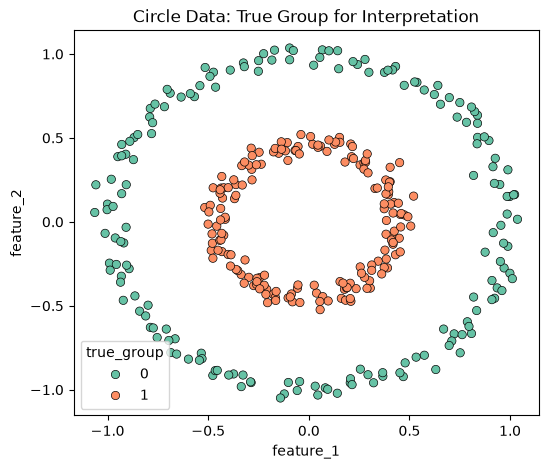

scaled mean: 0.0
scaled std: 1.0


In [22]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=circle_df,
    x='feature_1',
    y='feature_2',
    hue='true_group',
    palette='Set2',
    edgecolor='black'
)
plt.title('Circle Data: True Group for Interpretation')
plt.show()

circle_scaler = StandardScaler()
circle_X_scaled = circle_scaler.fit_transform(circle_X)

circle_scaled_df = pd.DataFrame(circle_X_scaled, columns=['feature_1_scaled', 'feature_2_scaled'])
circle_scaled_df['true_group'] = circle_y

print('scaled mean:', round(circle_X_scaled.mean(), 4) + 0.0)
print('scaled std:', round(circle_X_scaled.std(), 4))

## 문제 2. KMeans와 DBSCAN 결과 비교

같은 원형 데이터에 KMeans와 DBSCAN을 각각 적용하고 결과를 비교하세요.

요구사항:
- KMeans는 `n_clusters=2`, `n_init=10`, `random_state=42`
- DBSCAN은 `eps=0.32`, `min_samples=5`
- 결과를 `circle_compare_df`에 저장
- 두 결과를 나란히 산점도로 시각화

### 실행 결과
```text
KMeans cluster count 예시: {0: 180, 1: 170}
DBSCAN label count 예시: {0: 175, 1: 175}
그래프 제목:
- KMeans on Circle Data
- DBSCAN on Circle Data
```


KMeans cluster count: {0: 178, 1: 172}
DBSCAN label count: {0: 175, 1: 175}


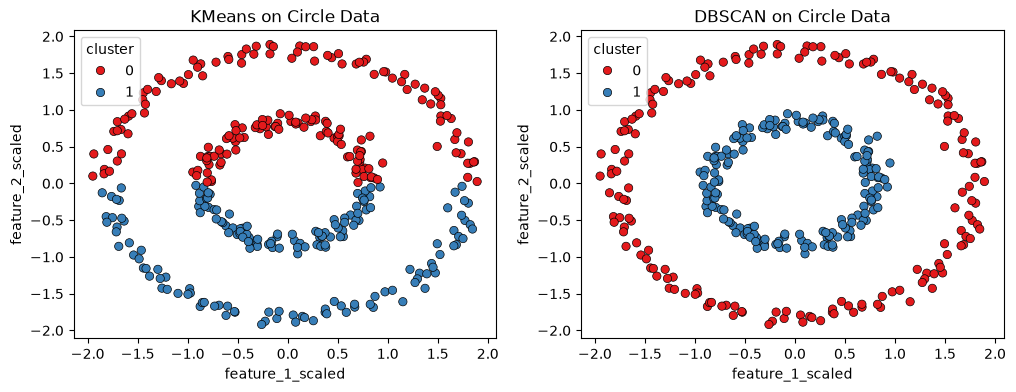

In [26]:
kmeans_circle = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10,
)

circle_kmeans_labels = kmeans_circle.fit_predict(circle_X_scaled)

# DBSCAN : eps 반경 내에 min_samples 이상의 이웃 데이터가 있으면 같은 밀도 영역으로 봄
dbscan_circle = DBSCAN(
    eps=0.32,
    min_samples=5,
)

circle_dbscan_labels = dbscan_circle.fit_predict(circle_X_scaled)

circle_compare_df = circle_scaled_df.copy()
circle_compare_df['kmeans_cluster'] = circle_kmeans_labels
circle_compare_df['dbscan_cluster'] = circle_dbscan_labels

print('KMeans cluster count:', circle_compare_df['kmeans_cluster'].value_counts().sort_index().to_dict())
print('DBSCAN label count:', circle_compare_df['dbscan_cluster'].value_counts().sort_index().to_dict())

# 시각화
fig, axes = plt.subplots(1,2,figsize=(12,4))

sns.scatterplot(
    data=circle_compare_df,
    x='feature_1_scaled',
    y='feature_2_scaled',
    hue='kmeans_cluster',
    palette='Set1',
    edgecolor='black',
    ax=axes[0]
)

axes[0].set_title('KMeans on Circle Data')
axes[0].legend(title='cluster')

sns.scatterplot(
    data=circle_compare_df,
    x='feature_1_scaled',
    y='feature_2_scaled',
    hue='dbscan_cluster',
    palette='Set1',
    edgecolor='black',
    ax=axes[1]
)

axes[1].set_title('DBSCAN on Circle Data')
axes[1].legend(title='cluster')

# plt.tight_layout()
plt.show()

# KMeans는 중심점 기준으로 군집을 형성하기 때문에
# 원형(안쪽 원/바깥쪽 원) 데이터에 적합하지 않다

# DBSCAN은 밀도가 이어지는 영역을 따라 군집을 자동적으로 형성하기 때문에
# 원형, 반달 같은 곡선형 데이터에 적합하다
# -1 == Noise Point

## 문제 3. `eps`, `min_samples` 변화 비교

DBSCAN의 `eps`, `min_samples` 설정을 바꾸며 군집 개수와 노이즈 개수를 비교하세요.

요구사항:
- 후보: `(0.16, 5)`, `(0.24, 5)`, `(0.32, 5)`, `(0.70, 5)`, `(0.32, 10)`
- 결과 컬럼: `eps`, `min_samples`, `cluster_count`, `noise_count`
- 결과 변수명은 `circle_param_result_df`

### 실행 결과
```text
    eps  min_samples  cluster_count  noise_count
0  0.16            5             20           54
1  0.24            5              6            0
2  0.32            5              2            0
3  0.70            5              1            0
4  0.32           10              8            5
```


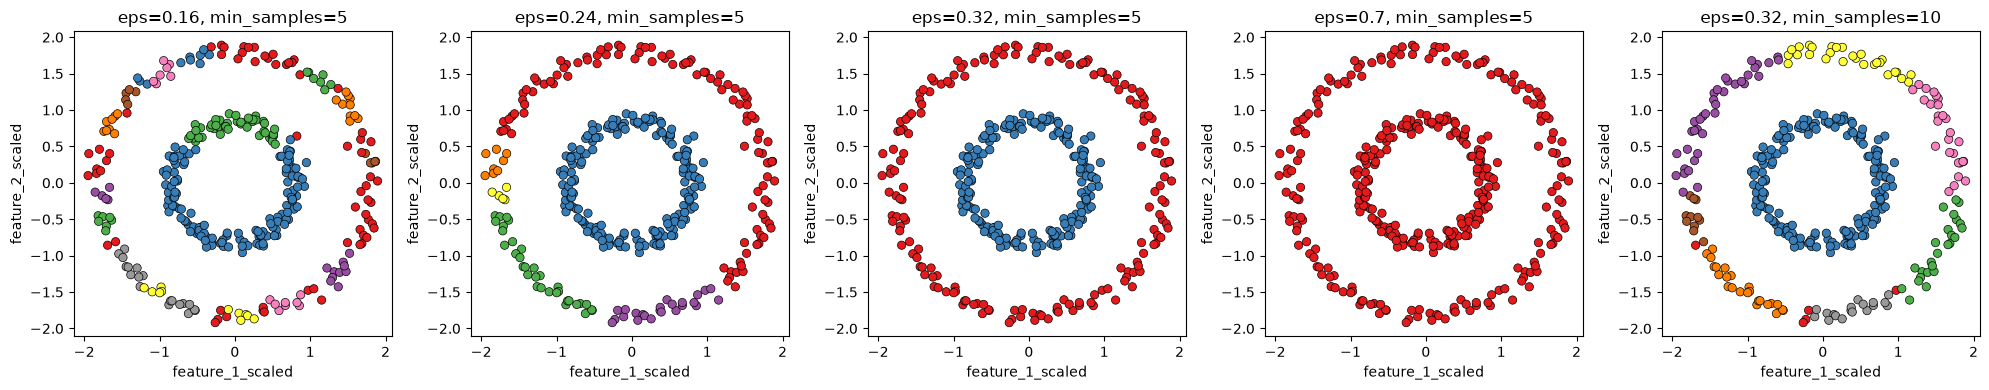

,eps,min_samples,cluster_count,noise_count
0,0.16,5,20,54
1,0.24,5,6,0
2,0.32,5,2,0
3,0.70,5,1,0
4,0.32,10,8,5


In [24]:
# eps, min_samples의 변화에 따라 DBSCAN 결과가 어떻게 달라지는지 비교
param_results = []
param_candidates = [
    {'eps':0.16, 'min_samples':5},
    {'eps':0.24, 'min_samples':5},
    {'eps':0.32, 'min_samples':5},
    {'eps':0.70, 'min_samples':5},
    {'eps':0.32, 'min_samples':10},
]

fig, axes = plt.subplots(1,5,figsize=(20,4))

for ax, params in zip(axes, param_candidates):
    model = DBSCAN(
        eps=params['eps'],
        min_samples=params['min_samples'],
    )

    labels = model.fit_predict(circle_X_scaled) # 학습 + 군집 예측

    # 군집 개수
    cluster_count = len(set(labels) - {-1})

    # 노이즈의 개수
    noise_count = np.sum(labels == -1)

    param_results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'cluster_count': cluster_count,
        'noise_count': noise_count,
    })

    plot_df = circle_scaled_df.copy()
    plot_df['cluster'] = labels
    sns.scatterplot(
        data=plot_df,
        x='feature_1_scaled',
        y='feature_2_scaled',
        hue='cluster',
        palette='Set1',
        edgecolor='black',
        legend=False,
        ax=ax
    )

    ax.set_title(f'eps={params["eps"]}, min_samples={params["min_samples"]}')

plt.tight_layout()
plt.show()
display(pd.DataFrame(param_results))

## 문제 4. 최종 DBSCAN 결과 해석

`eps=0.32`, `min_samples=5` 결과를 실제 `true_group`과 교차표로 비교하세요.

요구사항:
- `pd.crosstab()` 사용
- 행은 실제 그룹, 열은 DBSCAN label
- 결과 변수명은 `circle_dbscan_table`

### 실행 결과
```text
dbscan_cluster    0    1
true_group              
0               175    0
1                 0  175
```


In [25]:
from sklearn.metrics import silhouette_score

circle_dbscan_table = pd.crosstab(
    circle_compare_df['true_group'],
    circle_compare_df['dbscan_cluster'],
    rownames=['true_group'],
    colnames=['dbscan_cluster'],
)

display(circle_dbscan_table)

# 노이즈가 아닌 군집이 2개 이상일 때만 silhouette_score를 참고용으로 계산함.
non_noise_mask = circle_compare_df['dbscan_cluster'] != -1
non_noise_labels = circle_compare_df.loc[non_noise_mask, 'dbscan_cluster']

if non_noise_labels.nunique() >= 2:
    score = silhouette_score(circle_X_scaled[non_noise_mask], non_noise_labels)
    print(f'노이즈 제외 silhouette_score: {score:.4f}')
else:
    print('노이즈를 제외한 군집 수가 2개 미만이라 silhouette_score를 계산하지 않음.')

dbscan_cluster,0,1
true_group,,
0,175,0
1,0,175


노이즈 제외 silhouette_score: 0.1315
